# Úkol 3: Komplexní evaluace, komparace a diskuze modelů

**Projekt:** Predikce výnosu zemědělských plodin v Indii  
**Typ úlohy:** regrese  
**Autor:** Peter Briedoň

Cílem notebooku je férově porovnat dosud probírané rodiny modelů, vyhodnotit
jejich generalizaci na chronologicky pozdějším testovacím období a kriticky
interpretovat výsledky. Neuronové sítě nejsou podle zadání zahrnuty.

Notebook **netrénuje nové konfigurace a neprovádí další tuning**. Načítá
výsledky modelů, jejichž seznam, preprocessing, feature set a hyperparametry
byly zmrazeny před zpřístupněním testovací sady.


## 1. Task framing

Jednotkou pozorování je kombinace státu, okresu, roku, sezóny a plodiny.
Cílovou proměnnou je `target_yield`, tedy korigovaný výnos vypočtený z
opravené produkce a plochy.

Projekt odpovídá regresní úloze: pro nové pozorování chceme odhadnout spojitou
hodnotu výnosu. Primární metrikou je MAE. Doplňkově používáme RMSE, R² a
MedianAE.

- **MAE** vyjadřuje průměrnou absolutní velikost chyby.
- **RMSE** výrazněji penalizuje velké chyby.
- **R²** porovnává model s konstantní predikcí průměru.
- **MedianAE** popisuje typickou chybu a je méně citlivá na extrémy.


## Reprodukční spuštění zmrazených modelů

Zadání požaduje, aby byly modely v notebooku natrénovány nebo znovu načteny.
Proto následující buňka skutečně znovu vytvoří všechny pipeline ze zmrazeného
plánu, natrénuje deset full-data modelů na období 1997–2012 a vyhodnotí je na
celé testovací sadě 2013–2014.

Hyperparametry se v notebooku nehledají ani nemění. Před spuštěním se ověří,
že modelové specifikace přesně odpovídají souboru
`hw3_frozen_evaluation_plan.json`. Nově vypočtené full-data metriky se následně
porovnají s uloženým finálním reportem.

KNN a RBF-SVR zůstávají resource-limited podle velikosti trénovacího vzorku
(5 000 řádků), ale notebook je navíc vyhodnotí na všech 32 596 testovacích
řádcích. Jde pouze o doplňkovou evaluaci předem zmrazených konfigurací, nikoli
o nové model selection.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from run_hw3_final_test import (
    load_inputs,
    validate_specs_against_plan,
)
from run_hw3_pretest_selection import (
    FEATURE_SET_NAME,
    TARGET,
    deterministic_sample,
    full_model_specs,
    regression_metrics,
    resource_model_specs,
)

train_frame, validation_frame, test_frame, notebook_manifest, notebook_plan = (
    load_inputs()
)
final_train_frame = pd.concat(
    [train_frame, validation_frame],
    ignore_index=True,
)

feature_set = list(
    notebook_manifest["feature_sets"][FEATURE_SET_NAME]
)
categorical_features = list(
    notebook_manifest["categorical_features"]
)
numeric_features = [
    column
    for column in feature_set
    if column not in categorical_features
]

full_specs = full_model_specs(
    categorical_features,
    numeric_features,
)
resource_specs = resource_model_specs(
    categorical_features,
    numeric_features,
)

validate_specs_against_plan(
    full_specs,
    notebook_plan["full_validation_models"],
)
validate_specs_against_plan(
    resource_specs,
    notebook_plan["resource_limited_validation_models"],
)


def fit_and_evaluate_specs(
    specs,
    fit_frame,
    evaluation_frame,
    scope,
):
    rows = []
    X_fit = fit_frame[feature_set]
    y_fit = fit_frame[TARGET]
    X_evaluation = evaluation_frame[feature_set]
    y_evaluation = evaluation_frame[TARGET]

    for spec in specs:
        estimator = spec.build_estimator()

        started = time.perf_counter()
        if spec.preprocessing_family == "none":
            estimator.fit(
                np.zeros((len(fit_frame), 1)),
                y_fit,
            )
        else:
            estimator.fit(X_fit, y_fit)
        fit_seconds = time.perf_counter() - started

        if spec.preprocessing_family == "none":
            fit_prediction = estimator.predict(
                np.zeros((len(fit_frame), 1))
            )
            evaluation_prediction = estimator.predict(
                np.zeros((len(evaluation_frame), 1))
            )
        else:
            fit_prediction = estimator.predict(X_fit)
            evaluation_prediction = estimator.predict(X_evaluation)

        fit_metrics = regression_metrics(
            y_fit,
            fit_prediction,
        )
        evaluation_metrics = regression_metrics(
            y_evaluation,
            evaluation_prediction,
        )

        rows.append(
            {
                "model_run_id": spec.run_id,
                "model_name": spec.model_name,
                "model_family": spec.model_family,
                "evaluation_scope": scope,
                "train_rows_used": len(fit_frame),
                "test_rows_used": len(evaluation_frame),
                "fit_seconds": fit_seconds,
                "train_mae": fit_metrics["mae"],
                "train_rmse": fit_metrics["rmse"],
                "train_r2": fit_metrics["r2"],
                "train_median_ae": fit_metrics["median_ae"],
                "test_mae": evaluation_metrics["mae"],
                "test_rmse": evaluation_metrics["rmse"],
                "test_r2": evaluation_metrics["r2"],
                "test_median_ae": evaluation_metrics["median_ae"],
                "status": "completed",
            }
        )

        del estimator
        gc.collect()

    return pd.DataFrame(rows)


notebook_full_results = fit_and_evaluate_specs(
    full_specs,
    final_train_frame,
    test_frame,
    "notebook_recomputed_full_test",
)

stored_full_results = pd.read_csv(
    ROOT / "reports" / "hw3_final_full_test_results.csv"
)

verification = notebook_full_results.merge(
    stored_full_results[
        [
            "model_run_id",
            "test_mae",
            "test_rmse",
            "test_r2",
            "test_median_ae",
        ]
    ],
    on="model_run_id",
    suffixes=("_notebook", "_stored"),
    validate="one_to_one",
)

for metric in ["test_mae", "test_rmse", "test_r2", "test_median_ae"]:
    verification[f"{metric}_abs_difference"] = (
        verification[f"{metric}_notebook"]
        - verification[f"{metric}_stored"]
    ).abs()

difference_columns = [
    column
    for column in verification.columns
    if column.endswith("_abs_difference")
]
maximum_difference = float(
    verification[difference_columns].to_numpy().max()
)
assert maximum_difference < 1e-5, (
    "Nově vypočtené full-data metriky se liší od uloženého "
    f"auditu; max rozdíl={maximum_difference}"
)

resource_train_frame = deterministic_sample(
    final_train_frame,
    5000,
)
resource_full_test_results = fit_and_evaluate_specs(
    resource_specs,
    resource_train_frame,
    test_frame,
    "notebook_resource_train_full_test",
)

print(
    "Full-data modely byly znovu natrénovány a jejich metriky "
    "souhlasí s uloženým auditem."
)
print(
    f"Maximální absolutní rozdíl metrik: {maximum_difference:.10f}"
)
print(
    "Resource-limited modely byly natrénovány na 5 000 řádcích "
    f"a vyhodnoceny na všech {len(test_frame):,} testovacích řádcích."
)

display(
    notebook_full_results[
        [
            "model_name",
            "train_rows_used",
            "test_rows_used",
            "fit_seconds",
            "test_mae",
            "test_rmse",
            "test_r2",
            "test_median_ae",
        ]
    ]
    .sort_values("test_mae")
    .reset_index(drop=True)
)

display(
    resource_full_test_results[
        [
            "model_name",
            "train_rows_used",
            "test_rows_used",
            "fit_seconds",
            "train_mae",
            "test_mae",
            "test_rmse",
            "test_r2",
        ]
    ]
    .sort_values("test_mae")
    .reset_index(drop=True)
)


Full-data modely byly znovu natrénovány a jejich metriky souhlasí s uloženým auditem.
Maximální absolutní rozdíl metrik: 0.0000000000
Resource-limited modely byly natrénovány na 5 000 řádcích a vyhodnoceny na všech 32,596 testovacích řádcích.


,model_name,train_rows_used,test_rows_used,fit_seconds,test_mae,test_rmse,test_r2,test_median_ae
0,Random Forest,234552,32596,202.455544,1.611674,5.277702,0.839797,0.424710
1,Decision Tree,234552,32596,14.870879,1.612646,6.138621,0.783268,0.321230
2,LinearSVR,234552,32596,8.331093,2.505427,7.923610,0.638901,0.429133
3,Lasso,234552,32596,15.568062,2.946074,7.185825,0.703015,1.236091
4,Gradient Boosting,234552,32596,152.145940,2.951746,7.400100,0.685040,1.079457
5,Elastic Net,234552,32596,13.728293,3.065463,7.574680,0.670004,1.298478
6,Ridge,234552,32596,5.996402,3.154957,7.071487,0.712391,1.592953
7,Linear Regression,234552,32596,17.563400,3.167277,7.076283,0.712001,1.592805
8,DummyRegressor (median),234552,32596,0.006853,4.519306,13.827940,-0.099754,0.641749
9,DummyRegressor (mean),234552,32596,0.002166,5.938865,13.200952,-0.002285,3.659358


,model_name,train_rows_used,test_rows_used,fit_seconds,train_mae,test_mae,test_rmse,test_r2
0,Decision Tree (sample),5000,32596,0.213152,1.868955,2.596639,7.111595,0.709120
1,KNN (sample),5000,32596,0.078474,0.000000,4.137332,10.255836,0.395045
2,DummyRegressor median (sample),5000,32596,0.000810,3.874908,4.519306,13.827940,-0.099754
3,SVR RBF (sample),5000,32596,0.984577,4.545927,5.541523,9.605025,0.469387
4,DummyRegressor mean (sample),5000,32596,0.000474,5.571864,5.847297,13.208856,-0.003485


In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

ROOT = Path.cwd()
REPORTS = ROOT / "reports"
REFERENCE = ROOT / "data" / "reference"

def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def show_image(filename, width=900):
    path = REPORTS / filename
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f"Graf nebyl nalezen: {path}")

frozen_plan = read_json(REFERENCE / "hw3_frozen_evaluation_plan.json")
final_record = read_json(REFERENCE / "hw3_final_evaluation_record.json")
feature_manifest = read_json(REFERENCE / "model_feature_manifest.json")

validation_full = pd.read_csv(REPORTS / "hw3_pretest_full_validation_results.csv")
validation_resource = pd.read_csv(REPORTS / "hw3_pretest_resource_validation_results.csv")
test_full = pd.read_csv(REPORTS / "hw3_final_full_test_results.csv")
test_resource = pd.read_csv(REPORTS / "hw3_final_resource_test_results.csv")
validation_test = pd.read_csv(REPORTS / "hw3_validation_test_comparison.csv")
residual_quartiles = pd.read_csv(REPORTS / "hw3_residual_summary_by_target_quartile.csv")
target_distribution = pd.read_csv(REPORTS / "hw3_target_distribution_comparison.csv")
worst_predictions = pd.read_csv(REPORTS / "hw3_worst_predictions.csv")

print("Načtení reportů dokončeno.")
print(f"Full-data modely: {len(test_full)}")
print(f"Resource-limited modely: {len(test_resource)}")


Načtení reportů dokončeno.
Full-data modely: 10
Resource-limited modely: 5


## 2. Data, feature set a ochrana proti leakage

Modelovací dataset používá chronologický split:

- **train:** 1997–2010,
- **validation:** 2011–2012,
- **finální fit:** 1997–2012,
- **test:** 2013–2014.

Při finálním fitu byly train a validation spojeny až po ukončení model
selection. Testovací období zůstalo do zmrazení konfigurací oddělené.

Definitivní target je `target_yield`. Mezi zakázané leakage proměnné patří
původní produkce, korigovaná produkce, původní `yield`, samotný target a
technické sloupce popisující reconciliaci zdrojů.

Pro hlavní srovnání se používá společný feature set `core_without_lag`.
Tím mají full-data modely stejnou informační základnu. Historický lag není
součástí tohoto hlavního srovnání, protože by reprezentoval odlišný aplikační
scénář.


In [3]:
summary = pd.DataFrame({
    "Položka": [
        "Target",
        "Primární metrika",
        "Train období",
        "Validation období",
        "Finální fit období",
        "Test období",
        "Počet řádků finálního fitu",
        "Počet testovacích řádků",
        "Feature set",
        "Počet features bez lagu",
        "Počet full-data modelů",
        "Počet resource-limited modelů",
    ],
    "Hodnota": [
        feature_manifest["target_column"],
        frozen_plan["primary_metric"],
        frozen_plan["train_period"],
        frozen_plan["validation_period"],
        final_record["final_fit_period"],
        final_record["final_test_period"],
        final_record["final_train_rows"],
        final_record["test_rows"],
        frozen_plan["feature_set"],
        len(feature_manifest["feature_sets"]["core_without_lag"]),
        final_record["full_model_count"],
        final_record["resource_model_count"],
    ],
})
display(summary)


,Položka,Hodnota
0,Target,target_yield
1,Primární metrika,MAE
2,Train období,1997-2010
3,Validation období,2011-2012
4,Finální fit období,1997-2012
5,Test období,2013-2014
6,Počet řádků finálního fitu,234552
7,Počet testovacích řádků,32596
8,Feature set,core_without_lag
9,Počet features bez lagu,31


## 3. Experimentální protokol

Model selection proběhl pouze na train a validation období. Před obnovením
testovacího souboru byl uložen zmrazený plán obsahující:

- přesný seznam modelů,
- preprocessing pro každou rodinu,
- feature set,
- hyperparametry,
- validační pořadí,
- pravidlo jednorázového finálního testu.

Po zpřístupnění testu se všechny zmrazené konfigurace jednou natrénovaly na
období 1997–2012 a vyhodnotily na letech 2013–2014. Výsledky testu nebyly
použity pro změnu konfigurací.


In [4]:
protocol = pd.DataFrame({
    "Kontrola": [
        "Konfigurace zmrazená před testem",
        "Test použit pro model selection",
        "Test použit pro tuning hyperparametrů",
        "Proběhl tuning po testu",
        "Model vybraný validací",
        "Model s nejnižším test MAE",
        "Random state",
    ],
    "Hodnota": [
        final_record["configuration_frozen_before_test"],
        final_record["test_used_for_model_selection"],
        final_record["test_used_for_hyperparameter_tuning"],
        final_record["post_test_tuning_performed"],
        final_record["selected_from_validation_run_id"],
        final_record["reported_test_best_run_id"],
        final_record["random_state"],
    ],
})
display(protocol)


,Kontrola,Hodnota
0,Konfigurace zmrazená před testem,True
1,Test použit pro model selection,False
2,Test použit pro tuning hyperparametrů,False
3,Proběhl tuning po testu,False
4,Model vybraný validací,random_forest_200_leaf_20
5,Model s nejnižším test MAE,random_forest_200_leaf_20
6,Random state,42


## 4. Zahrnuté modely

Hlavní full-data experiment zahrnuje:

- DummyRegressor s průměrem,
- DummyRegressor s mediánem,
- Linear Regression,
- Ridge,
- Lasso,
- Elastic Net,
- Decision Tree,
- Random Forest,
- Gradient Boosting,
- LinearSVR.

KNN a kernelový RBF-SVR byly vyhodnoceny odděleně na deterministickém vzorku,
protože jejich výpočetní náročnost je na plném one-hot zakódovaném datasetu
výrazně vyšší. Jejich výsledky proto nelze přímo míchat do hlavního pořadí.
Neuronové sítě nebyly podle zadání zahrnuty.


In [5]:
model_columns = [
    column for column in [
        "model_run_id", "model_name", "model_family", "preprocessing_family",
        "feature_set", "hyperparameters_json"
    ] if column in validation_full.columns
]
display(validation_full[model_columns].drop_duplicates().reset_index(drop=True))


,model_run_id,model_name,model_family,preprocessing_family,feature_set,hyperparameters_json
0,decision_tree_leaf_20,Decision Tree,tree,ordinal_unscaled,core_without_lag,"{""max_depth"": null, ""min_samples_leaf"": 20, ""r..."
1,dummy_mean,DummyRegressor (mean),baseline,none,core_without_lag,"{""strategy"": ""mean""}"
2,dummy_median,DummyRegressor (median),baseline,none,core_without_lag,"{""strategy"": ""median""}"
3,elastic_net_alpha_0_01_l1_0_5,Elastic Net,linear_regularized,onehot_scaled,core_without_lag,"{""alpha"": 0.01, ""l1_ratio"": 0.5, ""max_iter"": 1..."
4,gradient_boosting_60_lr_0_1_depth_3,Gradient Boosting,boosting_ensemble,ordinal_unscaled,core_without_lag,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti..."
5,lasso_alpha_0_01,Lasso,linear_regularized,onehot_scaled,core_without_lag,"{""alpha"": 0.01, ""max_iter"": 10000, ""selection""..."
6,linear_regression,Linear Regression,linear,onehot_scaled,core_without_lag,{}
7,linear_svr_c_0_03,LinearSVR,svm,onehot_scaled,core_without_lag,"{""C"": 0.03, ""dual"": ""auto"", ""epsilon"": 0.0, ""m..."
8,random_forest_200_leaf_20,Random Forest,bagging_ensemble,ordinal_unscaled,core_without_lag,"{""max_depth"": null, ""max_features"": 0.5, ""min_..."
9,ridge_alpha_1,Ridge,linear_regularized,onehot_scaled,core_without_lag,"{""alpha"": 1.0, ""solver"": ""lsqr""}"


## 5. Baseline

Baseline určuje, zda model přidává skutečnou predikční hodnotu. Použity byly
dvě naivní strategie:

- predikce průměru trénovacího targetu,
- predikce mediánu trénovacího targetu.

Reálný model má smysl pouze tehdy, pokud tyto jednoduché strategie přesvědčivě
překoná.


In [6]:
baseline_mask = test_full["model_family"].eq("baseline")
baseline_columns = [
    "model_name", "test_mae", "test_rmse", "test_r2", "test_median_ae"
]
display(
    test_full.loc[baseline_mask, baseline_columns]
    .sort_values("test_mae")
    .reset_index(drop=True)
)


,model_name,test_mae,test_rmse,test_r2,test_median_ae
0,DummyRegressor (median),4.519306,13.827940,-0.099754,0.641749
1,DummyRegressor (mean),5.938865,13.200952,-0.002285,3.659358


## 6. Výběr modelu na validation sadě

Hlavní model byl vybrán podle nejnižšího validačního MAE. Testovací data v této
fázi nebyla přítomna. Výběr na validaci je oddělený od následného reportování
testovacího pořadí.


In [7]:
validation_ranking = (
    validation_full.loc[validation_full["status"].eq("completed")]
    .sort_values("validation_mae")
    .reset_index(drop=True)
)

validation_view = [
    column for column in [
        "model_name", "validation_mae", "validation_rmse",
        "validation_r2", "validation_median_ae"
    ] if column in validation_ranking.columns
]
display(validation_ranking[validation_view])

selected_validation = validation_ranking.iloc[0]
print(
    f"Validací vybraný model: {selected_validation['model_name']} "
    f"(MAE={selected_validation['validation_mae']:.6f})"
)


,model_name,validation_mae,validation_rmse,validation_r2,validation_median_ae
0,Random Forest,1.618119,5.712142,0.794407,0.345543
1,Decision Tree,1.673477,6.229360,0.755490,0.286656
2,LinearSVR,2.339304,7.752574,0.621295,0.396991
3,Gradient Boosting,2.761550,7.277977,0.666243,0.945638
4,Lasso,2.979749,7.249110,0.668885,1.322582
5,Elastic Net,3.021564,7.515958,0.644059,1.300951
6,Ridge,3.175822,7.122269,0.680371,1.636061
7,Linear Regression,3.222497,7.136064,0.679132,1.693130
8,DummyRegressor (median),4.096406,13.134077,-0.086947,0.633207
9,DummyRegressor (mean),5.639314,12.599494,-0.000266,3.629937


Validací vybraný model: Random Forest (MAE=1.618119)


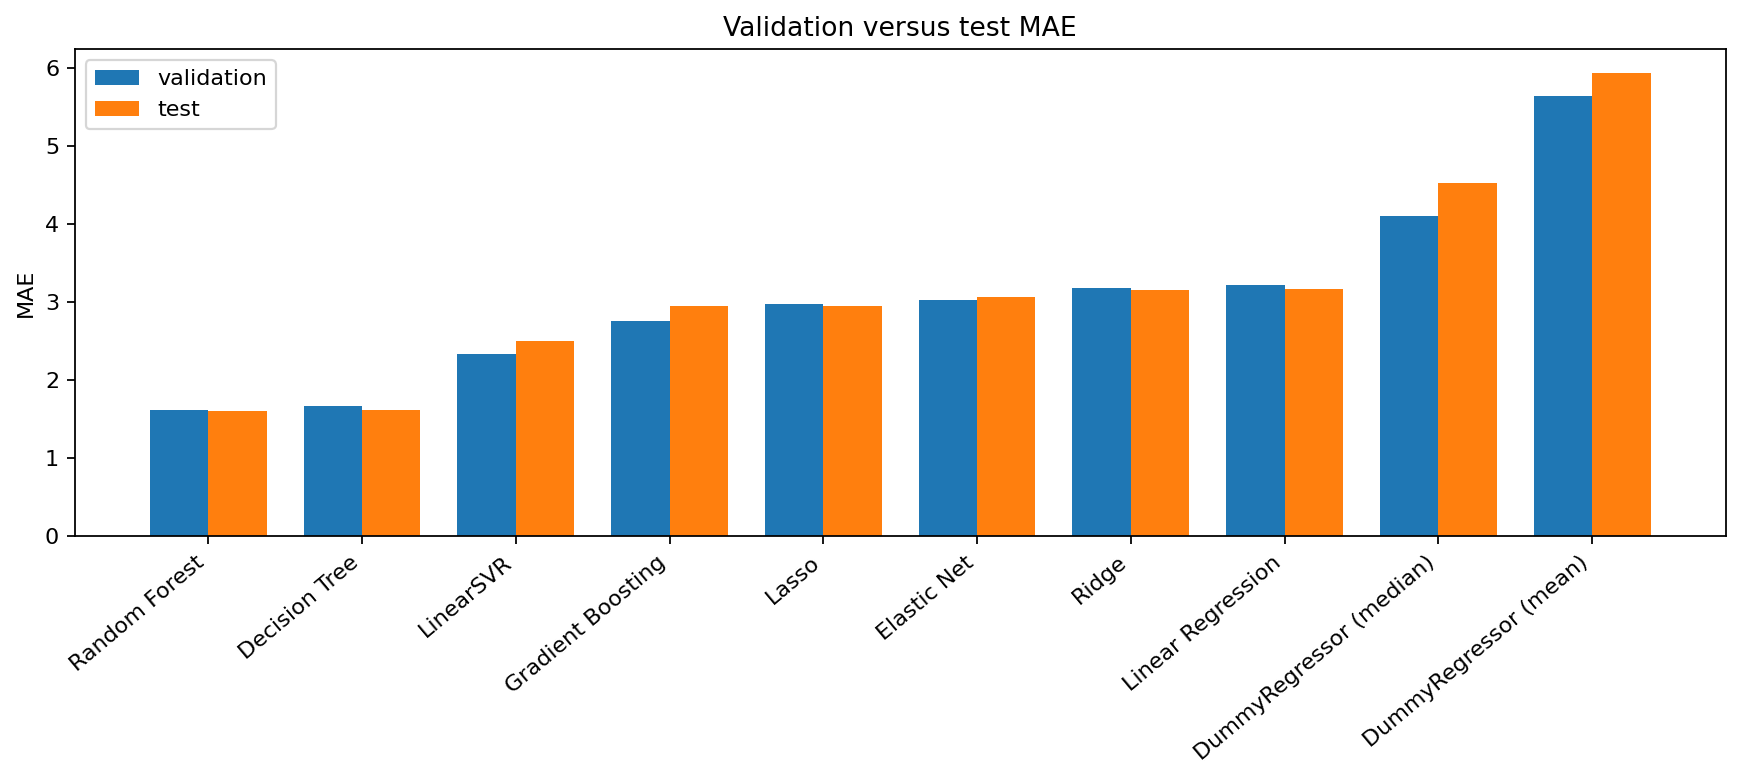

In [8]:
show_image("hw3_validation_vs_test_mae.png")


### Diskuze validačního výběru

Random Forest dosáhl nejnižšího validačního MAE (`1.618119`) a byl proto
vybrán ještě před otevřením testovací sady. Druhý skončil Decision Tree
s MAE `1.673477`. Už validační výsledky tedy ukázaly, že stromové modely
zachycují strukturu dat lépe než globální lineární vztah.

Důvodem je pravděpodobně charakter problému. Vliv teploty, srážek nebo plochy
nemusí být stejný pro všechny plodiny, okresy a sezóny. Strom dokáže vytvářet
rozdílná pravidla pro různé části dat a přirozeně zachytit prahové efekty
a interakce, například situaci, kdy vysoká teplota škodí pouze určité plodině
v určité sezóně. Lineární model naproti tomu předpokládá převážně aditivní
globální vztahy a bez ručně vytvořených interakcí takovou heterogenitu
zachytává hůře.

Random Forest průměruje predikce 200 stromů. Jednotlivé stromy nejsou totožné,
protože pracují s různými bootstrap vzorky a podmnožinami features.
Průměrování snižuje varianci a omezuje citlivost na konkrétní trénovací
pozorování. To vysvětluje, proč Random Forest překonal jeden Decision Tree,
aniž by bylo nutné výrazně omezit hloubku stromů.

Z lineárních a regularizovaných modelů dopadlo nejlépe Lasso. L1 regularizace
pravděpodobně pomohla potlačit méně užitečné koeficienty ve
vysoko-dimenzionálním one-hot prostoru. Ani Lasso však nemůže samo vytvářet
nelineární podmínky a interakce, takže za stromovými modely zaostalo.

LinearSVR měl nejlepší validační MAE mezi nestromovými modely. To naznačuje,
že jeho ztrátová funkce dobře omezuje typické absolutní chyby. Vyšší RMSE však
ukazuje, že některé velké chyby zůstaly. Výběr Random Forestu proto nestojí
pouze na jednom čísle, ale také na lepší kontrole extrémních odchylek.


## 7. Finální testovací výsledky

Následující pořadí je pouze výsledkem jednorázového finálního auditu. Nejde o
nové kolo model selection a po zobrazení výsledků nebyly změněny modely,
features ani hyperparametry.


In [9]:
test_ranking = (
    test_full.loc[test_full["status"].eq("completed")]
    .sort_values("test_mae")
    .reset_index(drop=True)
)

test_view = [
    "model_name", "test_mae", "test_rmse", "test_r2",
    "test_median_ae", "mae_generalization_gap"
]
test_view = [column for column in test_view if column in test_ranking.columns]
display(test_ranking[test_view])


,model_name,test_mae,test_rmse,test_r2,test_median_ae,mae_generalization_gap
0,Random Forest,1.611674,5.277702,0.839797,0.424710,0.481418
1,Decision Tree,1.612646,6.138621,0.783268,0.321230,0.660778
2,LinearSVR,2.505427,7.923610,0.638901,0.429133,0.297459
3,Lasso,2.946074,7.185825,0.703015,1.236091,0.087973
4,Gradient Boosting,2.951746,7.400100,0.685040,1.079457,0.206849
5,Elastic Net,3.065463,7.574680,0.670004,1.298478,0.076393
6,Ridge,3.154957,7.071487,0.712391,1.592953,0.108059
7,Linear Regression,3.167277,7.076283,0.712001,1.592805,0.122653
8,DummyRegressor (median),4.519306,13.827940,-0.099754,0.641749,0.507010
9,DummyRegressor (mean),5.938865,13.200952,-0.002285,3.659358,0.110458


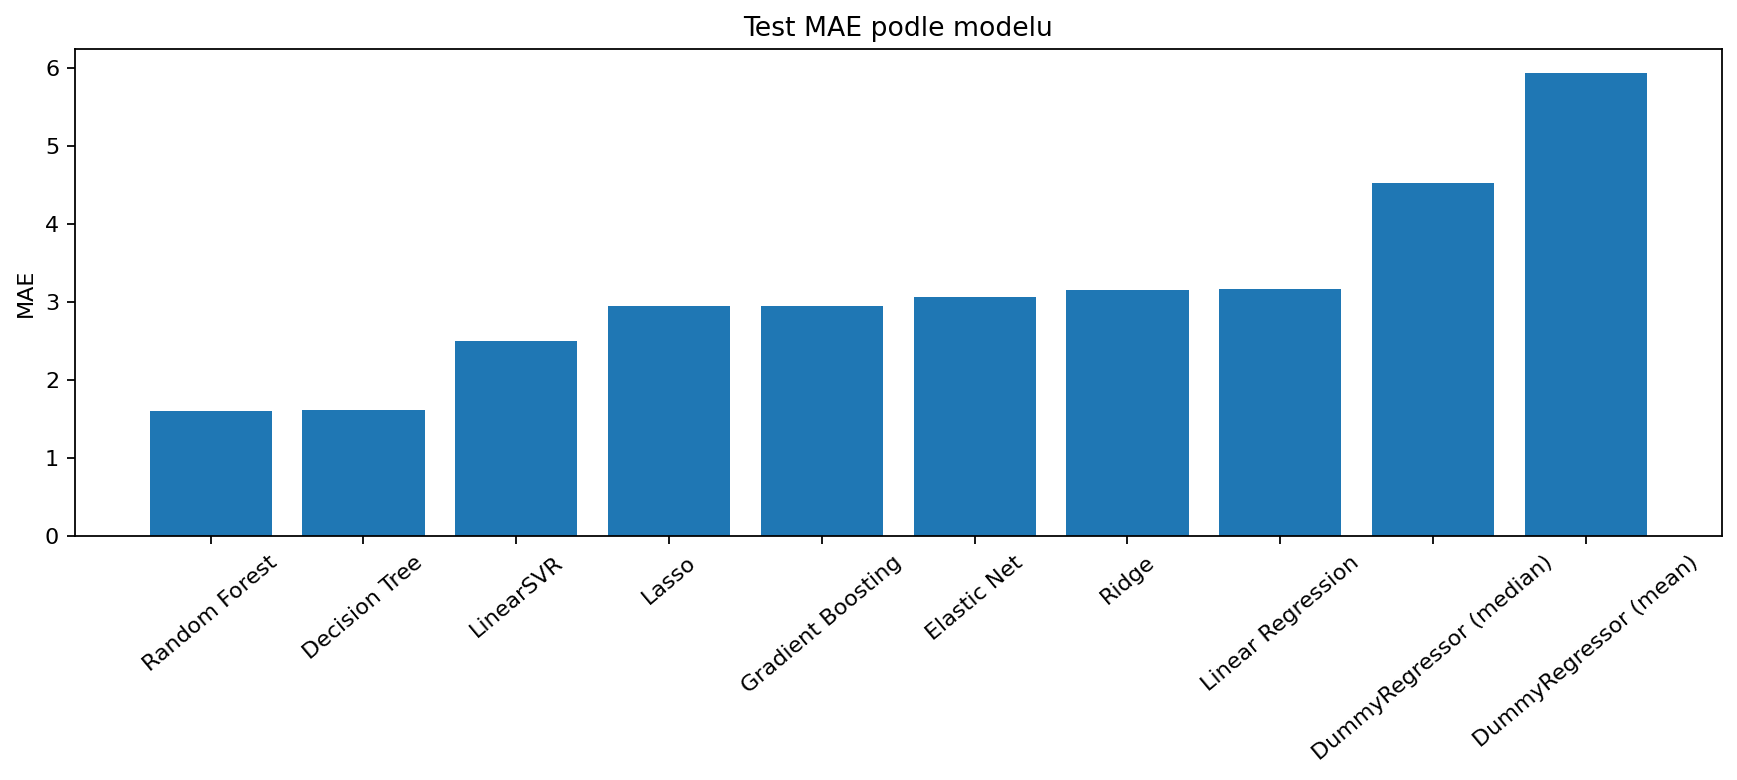

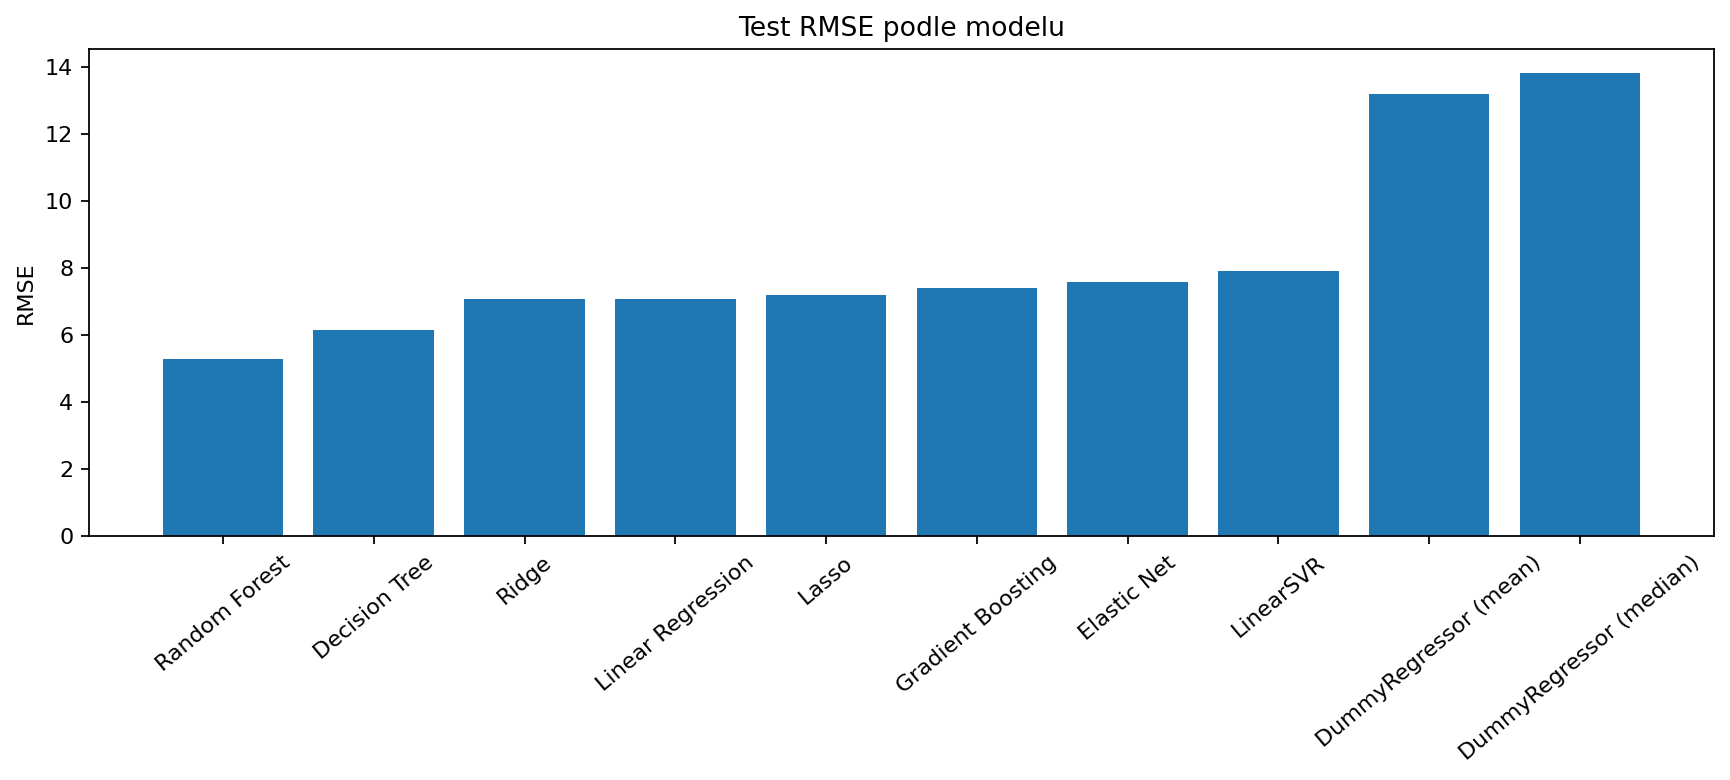

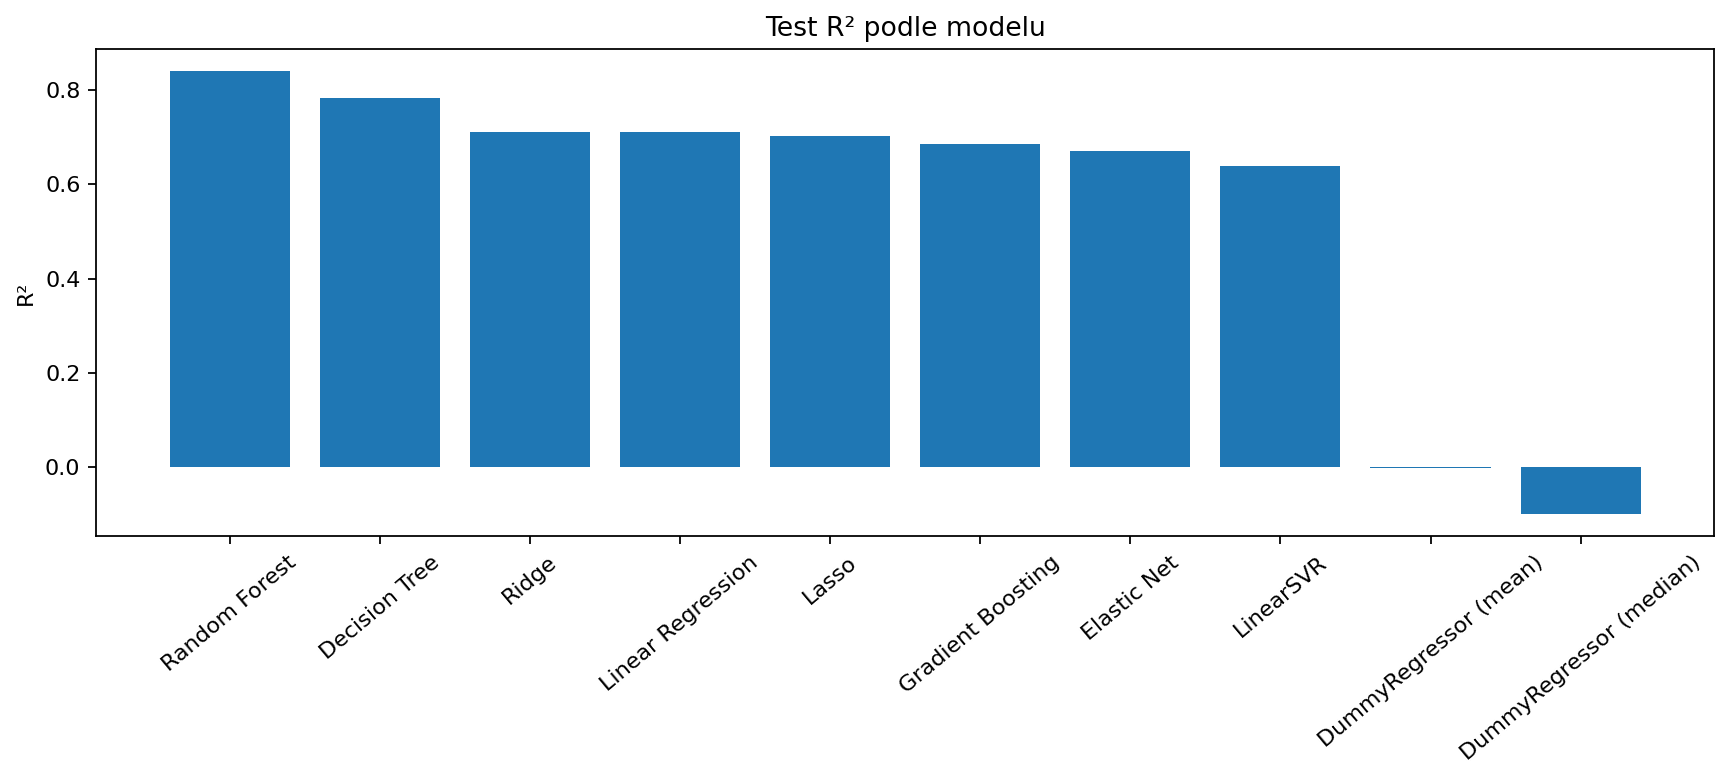

In [10]:
show_image("hw3_final_test_mae.png")
show_image("hw3_final_test_rmse.png")
show_image("hw3_final_test_r2.png")


### Diskuze finálního pořadí

Random Forest zůstal první i na finálním testu. Jeho MAE `1.611674` je téměř
shodné s MAE Decision Tree `1.612646`; rozdíl je pouze přibližně `0.000973`.
Podle samotného MAE proto nelze tvrdit, že Random Forest je prakticky výrazně
lepší v běžné absolutní chybě.

Rozdíl se ukáže až u RMSE a R². Random Forest má RMSE `5.277702`, zatímco
Decision Tree `6.138621`. Jde přibližně o 14% snížení RMSE. Random Forest má
také R² `0.839797`, oproti `0.783268` u jednoho stromu. To znamená, že soubor
stromů lépe omezuje několik velmi velkých chyb a vysvětluje větší část
variability targetu. Právě tato stabilita, nikoli zanedbatelný rozdíl MAE, je
hlavním důvodem pro volbu Random Forestu.

Výsledky baseline zároveň ukazují šikmé rozdělení targetu. Mediánová baseline
má nižší MAE než průměrová baseline, protože medián je odolnější vůči
extrémně vysokým výnosům. Průměrová baseline má naopak mírně lepší RMSE,
protože aritmetický průměr minimalizuje čtvercovou chybu. Obě baseline mají
R² kolem nuly nebo pod nulou, takže samy nevysvětlují strukturu dat.

Lineární regrese, Ridge, Lasso a Elastic Net baseline jasně překonaly, ale
jejich MAE zůstalo přibližně mezi `2.95` a `3.17`. Ridge a obyčejná lineární
regrese dopadly velmi podobně, takže L2 regularizace v této konfiguraci
nepřinesla zásadní zlepšení. Lasso bylo lepší, pravděpodobně díky výběrovému
účinku L1 regularizace, stále však pracuje s převážně lineárními a aditivními
vztahy.

LinearSVR dosáhl nižšího MAE než ostatní lineární modely, ale horšího RMSE.
To znamená, že často predikoval poměrně přesně, avšak u části pozorování
udělal velké chyby. Gradient Boosting v použité zmrazené konfiguraci také
nepřekonal Random Forest. Nelze z toho vyvozovat, že boosting je obecně horší;
výsledek platí pro konkrétní počet stromů, hloubku, learning rate a tento
dataset.


In [11]:
best = test_ranking.iloc[0]
tree = test_ranking.loc[test_ranking["model_name"].eq("Decision Tree")].iloc[0]
mean_baseline = test_ranking.loc[
    test_ranking["model_name"].str.contains("mean", case=False, na=False)
].iloc[0]
median_baseline = test_ranking.loc[
    test_ranking["model_name"].str.contains("median", case=False, na=False)
].iloc[0]

comparison = pd.DataFrame({
    "Porovnání": [
        "Random Forest vs Decision Tree – rozdíl MAE",
        "Random Forest vs Decision Tree – rozdíl RMSE",
        "Random Forest vs mean baseline – absolutní zlepšení MAE",
        "Random Forest vs mean baseline – relativní zlepšení MAE",
        "Random Forest vs median baseline – absolutní zlepšení MAE",
        "Random Forest vs median baseline – relativní zlepšení MAE",
    ],
    "Hodnota": [
        tree["test_mae"] - best["test_mae"],
        tree["test_rmse"] - best["test_rmse"],
        mean_baseline["test_mae"] - best["test_mae"],
        100 * (mean_baseline["test_mae"] - best["test_mae"]) / mean_baseline["test_mae"],
        median_baseline["test_mae"] - best["test_mae"],
        100 * (median_baseline["test_mae"] - best["test_mae"]) / median_baseline["test_mae"],
    ],
})
display(comparison)


,Porovnání,Hodnota
0,Random Forest vs Decision Tree – rozdíl MAE,0.000973
1,Random Forest vs Decision Tree – rozdíl RMSE,0.860919
2,Random Forest vs mean baseline – absolutní zle...,4.327191
3,Random Forest vs mean baseline – relativní zle...,72.862260
4,Random Forest vs median baseline – absolutní z...,2.907632
5,Random Forest vs median baseline – relativní z...,64.338028


## 8. Overfitting a stabilita mezi validation a testem

Overfitting hodnotíme porovnáním výkonu na trénovacích a dosud neviděných
datech. Současně je nutné oddělit klasické přeučení od časového dataset shiftu,
protože validation a test představují pozdější roky než train.

U Random Forestu bylo train MAE přibližně `1.130255`, validation MAE
`1.618119` a test MAE `1.611674`. Train chyba je podle očekávání nižší, takže
určitý generalizační rozdíl existuje. Mezi validation a test obdobím ale
nedošlo k dalšímu zhoršení. Random Forest proto nevykazuje výrazný
validation-to-test overfitting.

Decision Tree měl train MAE `0.951869` a test MAE `1.612646`. Jeho
train–test mezera je větší než u Random Forestu. Jeden strom se snáze
přizpůsobí specifickým strukturám trénovacích dat, zatímco průměrování ve
Random Forestu tuto varianci omezuje. Horší testovací RMSE Decision Tree tuto
vyšší citlivost na některé případy potvrzuje.

Nejsilnější známku přeučení v celém srovnání vykazuje resource-limited KNN.
Na trénovacím vzorku dosahuje nulové nebo téměř nulové MAE, zatímco na celé
testovací sadě je chyba výrazně vyšší, jak ukazuje samostatná resource tabulka.
Při distance weighting je trénovací bod sám sobě sousedem se vzdáleností nula,
takže model může trénovací data prakticky zapamatovat. Nulová train chyba proto
není důkazem kvality, ale naopak varováním před přeučením.

RBF-SVR má naopak vysokou chybu už na trénovacím vzorku i na celé testovací
sadě. To připomíná spíše underfitting nebo nevhodnou zmrazenou konfiguraci než
klasické přeučení.

Závěr tedy není, že se žádný model nepřeučil. Random Forest generalizuje
stabilně, Decision Tree vykazuje větší varianci a KNN představuje
nejzřetelnější případ přeučení v resource-limited experimentu.


In [12]:
stability_columns = [
    "model_name", "validation_mae", "test_mae",
    "test_minus_validation_mae", "validation_rmse", "test_rmse",
    "validation_r2", "test_r2"
]
stability_columns = [
    column for column in stability_columns if column in validation_test.columns
]
display(
    validation_test[stability_columns]
    .sort_values("test_mae")
    .reset_index(drop=True)
)


,model_name,validation_mae,test_mae,test_minus_validation_mae,validation_rmse,test_rmse,validation_r2,test_r2
0,Random Forest,1.618119,1.611674,-0.006446,5.712142,5.277702,0.794407,0.839797
1,Decision Tree,1.673477,1.612646,-0.060831,6.229360,6.138621,0.755490,0.783268
2,LinearSVR,2.339304,2.505427,0.166123,7.752574,7.923610,0.621295,0.638901
3,Lasso,2.979749,2.946074,-0.033675,7.249110,7.185825,0.668885,0.703015
4,Gradient Boosting,2.761550,2.951746,0.190196,7.277977,7.400100,0.666243,0.685040
5,Elastic Net,3.021564,3.065463,0.043899,7.515958,7.574680,0.644059,0.670004
6,Ridge,3.175822,3.154957,-0.020865,7.122269,7.071487,0.680371,0.712391
7,Linear Regression,3.222497,3.167277,-0.055221,7.136064,7.076283,0.679132,0.712001
8,DummyRegressor (median),4.096406,4.519306,0.422900,13.134077,13.827940,-0.086947,-0.099754
9,DummyRegressor (mean),5.639314,5.938865,0.299551,12.599494,13.200952,-0.000266,-0.002285


## 9. Analýza reziduí nejlepšího modelu

Reziduum je definováno jako:

`skutečná hodnota − predikce`

Kladné reziduum znamená podhodnocení skutečného výnosu. Záporné reziduum
znamená nadhodnocení.


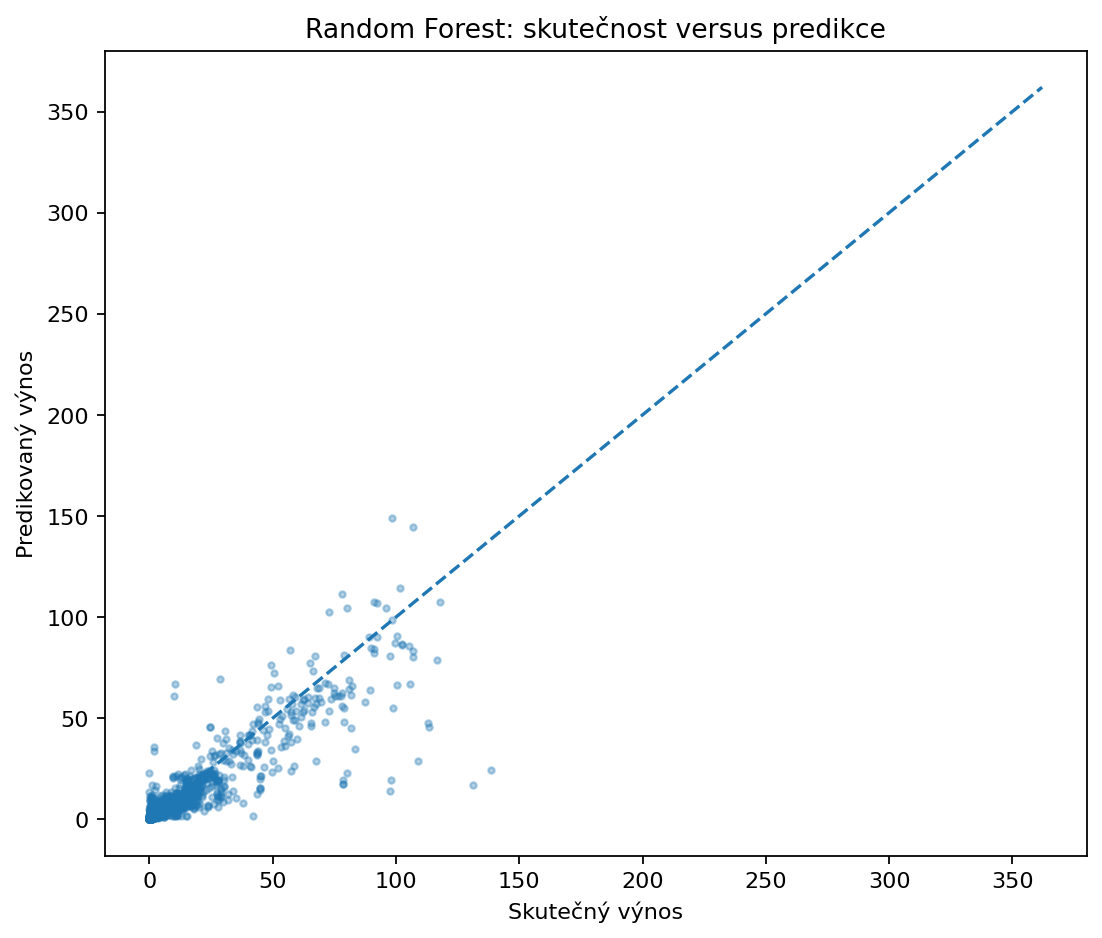

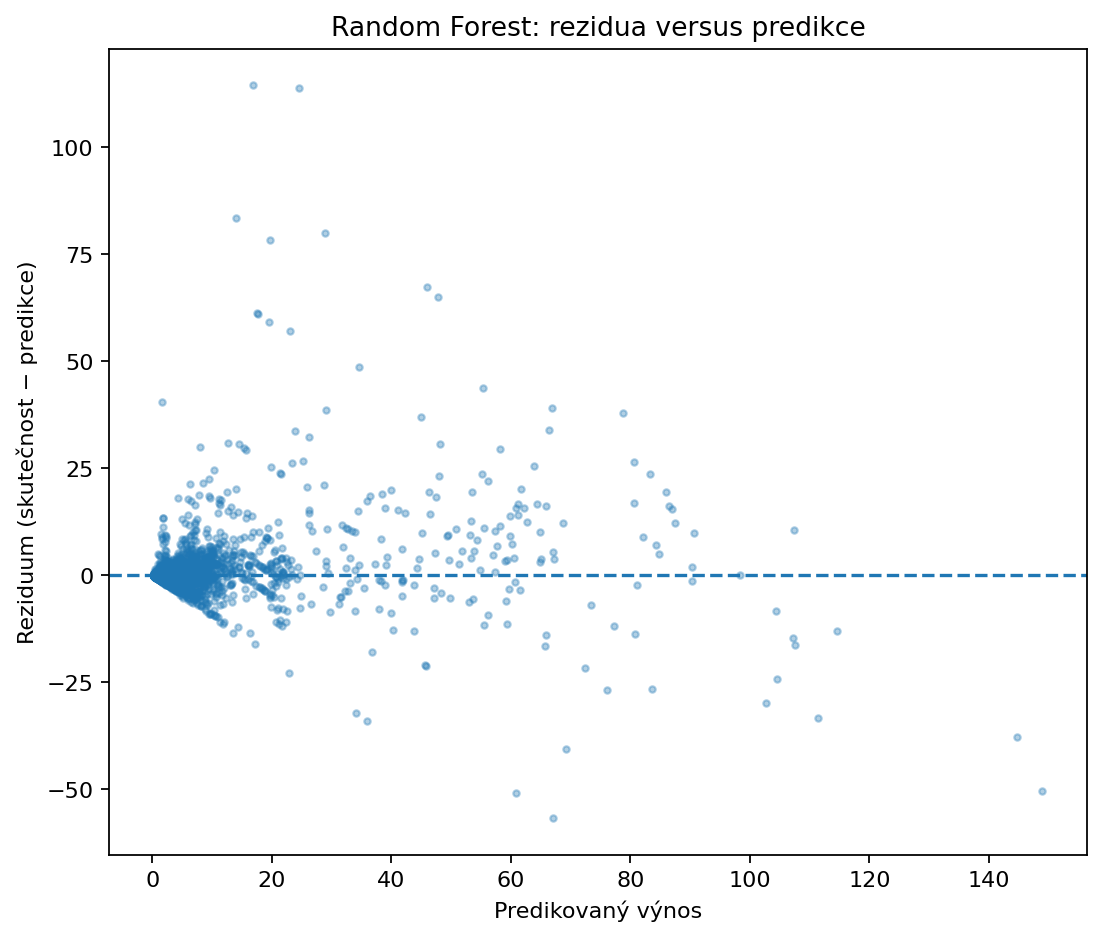

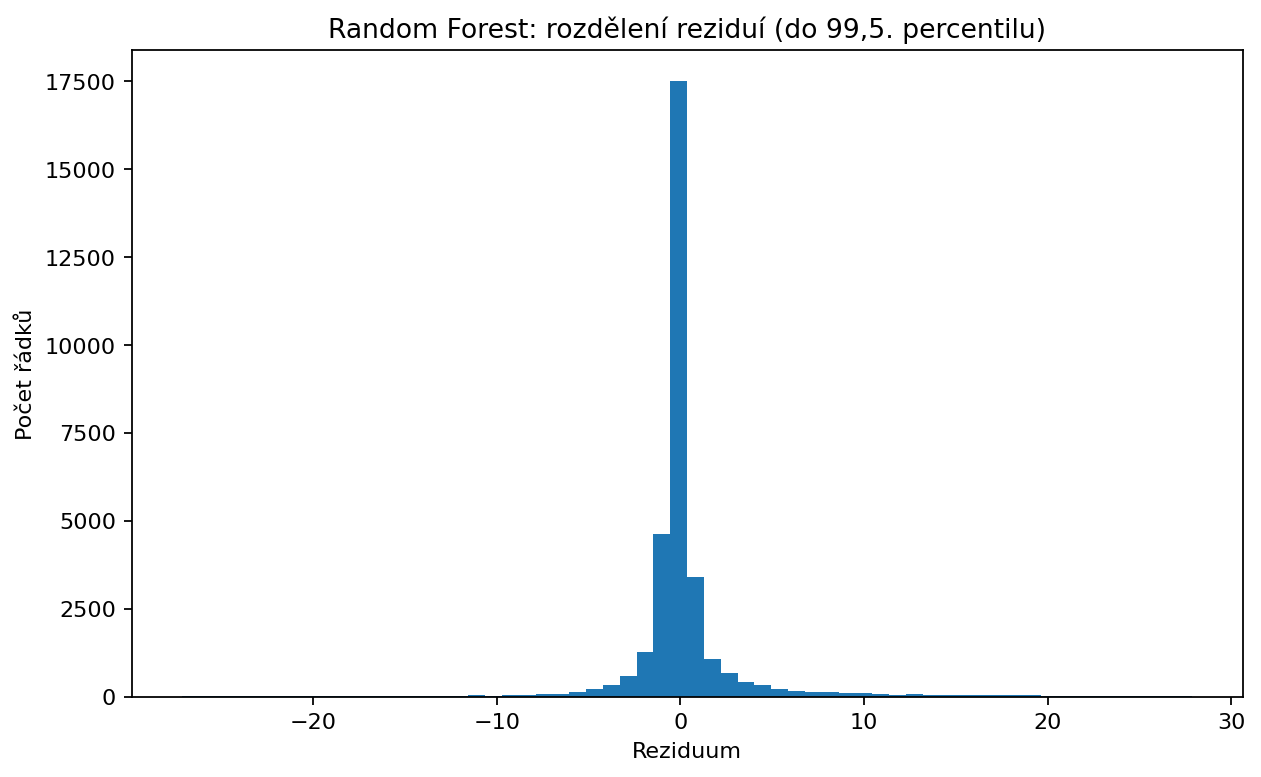

In [13]:
show_image("hw3_best_actual_vs_predicted.png")
show_image("hw3_best_residuals_vs_predicted.png")
show_image("hw3_best_residual_histogram.png")


In [14]:
display(residual_quartiles)


,target_quartile,rows,actual_min,actual_max,mae,rmse,mean_residual_actual_minus_prediction,underprediction_rate_pct
0,Q1 lowest,8151,0.000000,0.657143,0.561684,1.264081,-0.547826,9.716599
1,Q2,8147,0.657187,1.183097,0.495168,1.035650,-0.419643,25.935927
2,Q3,8195,1.183562,3.000000,0.678079,1.397594,-0.270822,50.262355
3,Q4 highest,8103,3.001194,362.000000,4.734646,10.362811,2.884718,73.590028


### Diskuze reziduí

Chyba není rovnoměrná v celém rozsahu targetu. Ve třech nižších kvartilech je
MAE relativně malé, zatímco v nejvyšším kvartilu výrazně roste. U nejvyšších
výnosů převládá podhodnocování.

To vysvětluje, proč může být celkové MAE nízké, ale RMSE zůstává podstatně
vyšší: menší počet extrémních chyb má silný vliv na RMSE. Model je proto
vhodnější pro běžné hodnoty výnosu než pro přesnou predikci nejvyšších
výnosových extrémů.


## 10. Nejhorší predikce

Analýza největších absolutních chyb pomáhá zjistit, zda model selhává náhodně,
nebo zda se chyby soustřeďují v určitých plodinách, lokalitách či rozsazích
targetu.


In [15]:
display(worst_predictions.head(20))


,canonical_crop_row_id,Crop_Year,canonical_state_name,canonical_district_name,Crop_canonical,Season_canonical,Area_corrected,target_yield,prediction,residual_actual_minus_prediction,absolute_error
0,CCR_CA158885324B1D3A634D,2013,Jharkhand,DHANBAD,Onion,Rabi,13.000000,362.000000,6.760353,355.239647,355.239647
1,CCR_4B6A3BF30123F90B4109,2013,West Bengal,MEDINIPUR WEST,Sugarcane,Whole Year,3210.000000,220.617757,84.505606,136.112151,136.112151
2,CCR_9A3F20604DD3B539FF6F,2013,Andhra Pradesh,PRAKASAM,Papaya,Kharif,918.000000,131.300654,16.916007,114.384646,114.384646
3,CCR_0992852B251D44541698,2013,Madhya Pradesh,KATNI,Banana,Whole Year,19.000000,138.421053,24.554139,113.866914,113.866914
4,CCR_96817A838F22F09E2CB7,2014,Andhra Pradesh,KADAPA,Papaya,Rabi,729.000000,107.111111,8.157673,98.953438,98.953438
5,CCR_FAA2E42A5ED206E91351,2014,West Bengal,MEDINIPUR WEST,Sugarcane,Whole Year,4390.000000,179.866515,83.525186,96.341329,96.341329
6,CCR_FCE7BEF0B7A70A69A925,2014,West Bengal,HOOGHLY,Sugarcane,Whole Year,830.000000,179.866265,84.722618,95.143648,95.143648
7,CCR_2AF8461E944214FBA4C1,2014,Andhra Pradesh,KADAPA,Papaya,Kharif,789.000000,107.111534,12.158327,94.953207,94.953207
8,CCR_2ACA96A17FD9483C1C51,2014,Andhra Pradesh,VIZIANAGARAM,Papaya,Rabi,127.000000,102.669291,9.239622,93.429670,93.429670
9,CCR_E521CA0AA3B2DD085BC2,2013,Andhra Pradesh,ANANTAPUR,Papaya,Kharif,230.000000,97.469565,13.969581,83.499984,83.499984


Nejhorší případy nelze automaticky označit jako chybu algoritmu. Mohou
zahrnovat neobvyklé klimatické podmínky, lokální faktory chybějící ve features,
historické změny měření, extrémní hodnoty nebo zbytkové problémy kvality dat.
Proto nejsou extrémy po zobrazení testu dodatečně mazány ani winsorizovány.


## 11. Distribuce targetu a dataset shift

Chronologické rozdělení znamená, že jednotlivá období nemusí mít stejnou
distribuci. Kontrola targetu pomáhá oddělit možné přeučení od přirozeného
časového posunu.


,split,rows,mean,std,min,p50,p90,p95,p99,max
0,train_1997_2010,202164,4.505971,19.356300,0.000000,0.996843,8.829255,19.790651,68.000000,2247.533300
1,validation_2011_2012,32388,4.711542,12.598011,0.000000,1.137926,9.533607,22.081163,70.413000,311.000000
2,final_train_1997_2012,234552,4.534358,18.570146,0.000000,1.000000,8.981842,20.000000,68.400000,2247.533300
3,test_2013_2014,32596,5.164614,13.186101,0.000000,1.183329,11.304705,23.390930,73.733333,362.000000


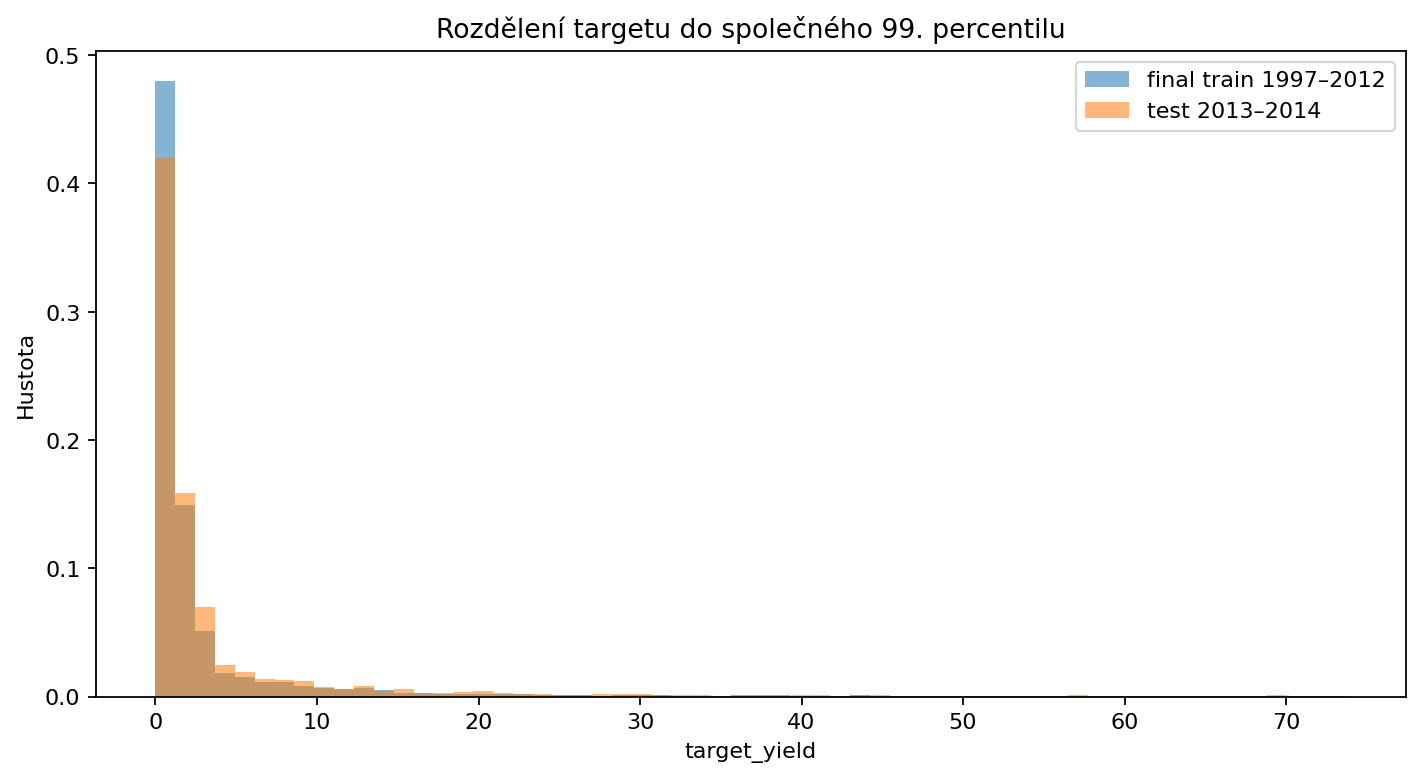

In [16]:
display(target_distribution)
show_image("hw3_target_distribution.png")


Testovací období má vyšší průměr, medián i horní percentily než starší části
dat. Současně trénovací období obsahuje extrémnější maximum. Tyto rozdíly
potvrzují, že náhodný split by nebyl vhodný: smíchal by časová období a mohl
by vytvořit příliš optimistický obraz generalizace.


## 12. Resource-limited experiment: KNN a RBF-SVR

KNN a kernelový SVR jsou zahrnuty kvůli úplnosti srovnání probíraných metod.
Kvůli výpočetní náročnosti byly natrénovány na samostatném deterministickém
vzorku 5 000 řádků. Notebook je však vyhodnocuje na celé testovací sadě
32 596 řádků. Spolu s nimi jsou za stejných podmínek natrénovány baseline
a Decision Tree.

Výsledky slouží k porovnání uvnitř resource-limited experimentu. Kvůli menšímu
trénovacímu vzorku nesmí být přímo zařazeny do pořadí full-data modelů.


In [17]:
resource_view = [
    "model_name",
    "train_rows_used",
    "test_rows_used",
    "train_mae",
    "test_mae",
    "test_rmse",
    "test_r2",
    "test_median_ae",
]
display(
    resource_full_test_results[resource_view]
    .sort_values("test_mae")
    .reset_index(drop=True)
)


,model_name,train_rows_used,test_rows_used,train_mae,test_mae,test_rmse,test_r2,test_median_ae
0,Decision Tree (sample),5000,32596,1.868955,2.596639,7.111595,0.709120,0.704772
1,KNN (sample),5000,32596,0.000000,4.137332,10.255836,0.395045,1.200661
2,DummyRegressor median (sample),5000,32596,3.874908,4.519306,13.827940,-0.099754,0.641749
3,SVR RBF (sample),5000,32596,4.545927,5.541523,9.605025,0.469387,4.284582
4,DummyRegressor mean (sample),5000,32596,5.571864,5.847297,13.208856,-0.003485,3.518618


In [18]:
resource_by_name = resource_full_test_results.set_index("model_name")
resource_tree = resource_by_name.loc["Decision Tree (sample)"]
resource_knn = resource_by_name.loc["KNN (sample)"]
resource_rbf = resource_by_name.loc["SVR RBF (sample)"]

display(
    Markdown(
        f'''
### Diskuze resource-limited experimentu

Decision Tree byl v doplňkovém experimentu nejlepší s test MAE
`{resource_tree['test_mae']:.6f}`. Model byl natrénován pouze na 5 000
řádcích, ale vyhodnocen na celé testovací sadě. Jeho horší výkon proti stromu
trénovanému na plných datech ukazuje, že omezení trénovacího vzorku vede ke
ztrátě užitečné informace o různých okresech, plodinách a podmínkách.

KNN dosáhl train MAE `{resource_knn['train_mae']:.6f}`, ale test MAE
`{resource_knn['test_mae']:.6f}`. Nulová nebo téměř nulová train chyba je
způsobena také tím, že při distance weighting je trénovací bod sám sobě
nejbližším sousedem se vzdáleností nula. Velký rozdíl mezi train a test
výkonem proto představuje nejsilnější známku přeučení v celém srovnání.

RBF-SVR dosáhl train MAE `{resource_rbf['train_mae']:.6f}` a test MAE
`{resource_rbf['test_mae']:.6f}`. Vysoká chyba už na trénovacích datech
odpovídá spíše underfittingu nebo nevhodné zmrazené konfiguraci než
klasickému přeučení.

Tyto výsledky neznamenají, že KNN nebo kernelový SVM jsou obecně nevhodné.
Platí pro předem zmrazené hyperparametry, použitý preprocessing a omezený
trénovací vzorek. Proto nejsou použity k přepsání hlavního full-data pořadí.
'''
    )
)



### Diskuze resource-limited experimentu

Decision Tree byl v doplňkovém experimentu nejlepší s test MAE
`2.596639`. Model byl natrénován pouze na 5 000
řádcích, ale vyhodnocen na celé testovací sadě. Jeho horší výkon proti stromu
trénovanému na plných datech ukazuje, že omezení trénovacího vzorku vede ke
ztrátě užitečné informace o různých okresech, plodinách a podmínkách.

KNN dosáhl train MAE `0.000000`, ale test MAE
`4.137332`. Nulová nebo téměř nulová train chyba je
způsobena také tím, že při distance weighting je trénovací bod sám sobě
nejbližším sousedem se vzdáleností nula. Velký rozdíl mezi train a test
výkonem proto představuje nejsilnější známku přeučení v celém srovnání.

RBF-SVR dosáhl train MAE `4.545927` a test MAE
`5.541523`. Vysoká chyba už na trénovacích datech
odpovídá spíše underfittingu nebo nevhodné zmrazené konfiguraci než
klasickému přeučení.

Tyto výsledky neznamenají, že KNN nebo kernelový SVM jsou obecně nevhodné.
Platí pro předem zmrazené hyperparametry, použitý preprocessing a omezený
trénovací vzorek. Proto nejsou použity k přepsání hlavního full-data pořadí.


## 13. Jak velký je rozdíl proti baseline a vyplatil se složitější model?

Rozdíl proti naivním baseline je výrazný. Random Forest snížil MAE z
`5.938865` u mean baseline na `1.611674`. Absolutní zlepšení je přibližně
`4.327191` a relativní zlepšení `72.86 %`.

Proti median baseline kleslo MAE z `4.519306` na `1.611674`. Absolutní
zlepšení je přibližně `2.907632`, tedy `64.34 %`. Nejde proto o malé
kosmetické zlepšení. Model využívá informace o plodině, lokalitě, sezóně,
roku a počasí a oproti konstantní predikci podstatně snižuje chybu.

Použití skutečného modelu se tedy proti baseline jednoznačně vyplatilo.
Složitější otázkou je, zda se vyplatil právě Random Forest místo jediného
Decision Tree. Rozdíl jejich MAE je prakticky nulový, takže pro aplikaci, kde
je prioritou jednoduchost, rychlost a interpretovatelnost, by mohl být jeden
strom dostatečný.

Random Forest však snížil RMSE proti Decision Tree přibližně o 14 % a zvýšil
R² přibližně o `0.0565`. Pokud jsou velké chyby nákladné nebo rizikové, je
tento rozdíl důležitý. Random Forest se proto vyplatí jako finální predikční
model hlavně kvůli stabilitě a menším extrémním chybám, nikoli kvůli
zanedbatelnému rozdílu v MAE.

Cena za tuto stabilitu je nižší interpretovatelnost, vyšší paměťová náročnost
a delší trénink. Volba mezi Random Forestem a jedním stromem tedy závisí i na
praktických požadavcích aplikace.


## 14. Omezení interpretace

- Model predikuje výnos, nikoli ekonomický zisk.
- Výsledky nejsou kauzálním důkazem vlivu počasí nebo lokality.
- Dataset neobsahuje úplné informace o zavlažování, hnojivech, pesticidech,
  pracovní síle, cenách, odrůdách a lokálních zásazích.
- Výkon na letech 2013–2014 nezaručuje stejný výkon v současnosti.
- Nejvyšší výnosy jsou podhodnocovány častěji než běžné hodnoty.
- Resource-limited modely nejsou přímo srovnatelné s full-data pořadím.
- Testovací sada byla použita jednorázově; další tuning podle těchto výsledků
  by porušil její roli nezávislého auditu.


## 15. Závěr

Random Forest byl vybrán podle validation MAE ještě před otevřením testu a na
finálním testu dosáhl nejlepší kombinace MAE, RMSE a R². Jeho výhodou je
schopnost zachytit nelineární vztahy a interakce mezi plodinou, lokalitou,
sezónou a počasím a současně omezit varianci jednotlivých stromů jejich
průměrováním.

Decision Tree měl prakticky stejné MAE a je interpretovatelnější. Random
Forest je však preferován kvůli výrazně lepšímu RMSE a R², tedy menším velkým
chybám. LinearSVR byl nejlepší nestromový model podle MAE, zatímco Lasso bylo
nejlepší mezi klasickými lineárními a regularizovanými modely.

Nejvýraznější overfitting se objevil u resource-limited KNN, které dosáhlo
nulové train chyby, ale podstatně horší test chyby. RBF-SVR naopak vykazovalo
spíše nedostatečné přizpůsobení v použité konfiguraci.

Rozdíl mezi Random Forestem a naivními baseline je dostatečně velký, aby
ospravedlnil použití strojového učení. Přínos Random Forestu proti jedinému
stromu spočívá hlavně v lepší kontrole extrémních chyb. Výsledky však platí
pro období 2013–2014 a použitý dataset; nejde o důkaz kauzality ani o záruku
stejného výkonu na současných datech.
